In [2]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

import synphot
from synphot.utils import download_data
file_list = download_data(None)
from synphot import SpectralElement, SourceSpectrum, Observation


W_cm2_um = u.W / u.cm**2 / u.um

https://ssb.stsci.edu/trds/calspec/alpha_lyr_stis_011.fits downloaded to /home/evanmayer/.astropy/cache/download/url/f172b14ae0e61ffc8702c9c648cf1afe/contents
https://ssb.stsci.edu/trds/extinction/lmc_30dorshell_001.fits downloaded to /home/evanmayer/.astropy/cache/download/url/ee4f1ecadf7d60d4feafeb52881acbfa/contents
https://ssb.stsci.edu/trds/extinction/lmc_diffuse_001.fits downloaded to /home/evanmayer/.astropy/cache/download/url/215cf6b5528e6b45dedb84035216f1e5/contents
https://ssb.stsci.edu/trds/extinction/milkyway_diffuse_001.fits downloaded to /home/evanmayer/.astropy/cache/download/url/20065c557d21d58cc73680ca0d19a2ca/contents
https://ssb.stsci.edu/trds/extinction/milkyway_dense_001.fits downloaded to /home/evanmayer/.astropy/cache/download/url/dd0bf7c9b0728c0bdb3e26e19059a822/contents
https://ssb.stsci.edu/trds/extinction/milkyway_rv21_001.fits downloaded to /home/evanmayer/.astropy/cache/download/url/1e53af77686f252f9303a202311c6727/contents
https://ssb.stsci.edu/trds/extinc

In [3]:
f = 83.1 * u.mm
fN = 1.4
D = 61.9 * u.mm # f / fN
A = np.pi * (D/2)**2
A = A.to(u.cm**2)
print(D, A)

61.9 mm 30.093394568552963 cm2


<Quantity 4.59521639e-20 W / (um cm2)>

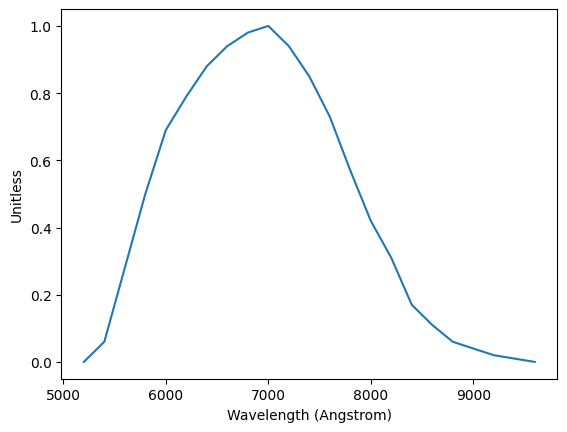

In [4]:
bp_r = SpectralElement.from_filter('johnson_r')
bp_r.plot()
bp_r.unit_response(A).to(W_cm2_um)

(3000.0, 10000.0)

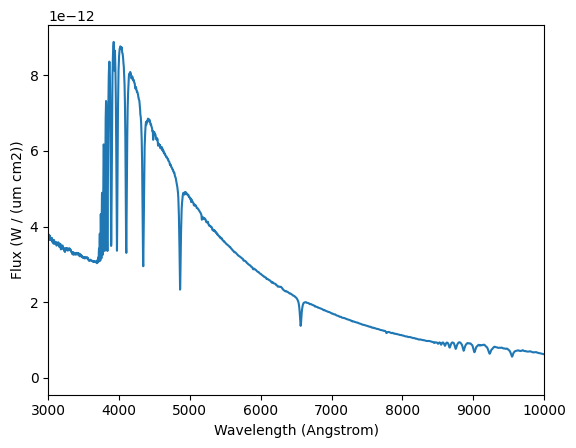

In [5]:
sp = SourceSpectrum.from_vega()
sp.plot(flux_unit=W_cm2_um)
ax = plt.gca()
ax.set_xlim(3000, 10000)

39317871.46300409 ct / s


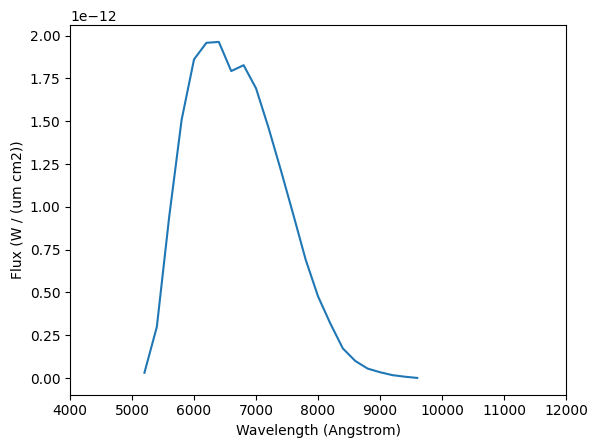

In [6]:
obs_vega = Observation(sp, bp_r)

obs_spec = obs_vega.as_spectrum()
obs_spec.plot(flux_unit=W_cm2_um)
plt.gca().set_xlim(4000, 12000)

vega_rate = obs_vega.countrate(A)
print(vega_rate)

In [7]:
# binflux = obs.sample_binned(flux_unit='count', area=A)
# # Sample the "native" flux for comparison
# flux = obs(obs.binset, flux_unit='count', area=A)
# plt.plot(obs.binset, flux, 'bx-', label='native')
# plt.plot(obs.binset, binflux, 'g-', drawstyle='steps-mid', label='binned')
# # plt.xlim(5342, 5372)
# # plt.ylim(5.598, 5.62)
# plt.xlabel('Wavelength (Angstrom)')
# plt.ylabel('Flux (count)')
# plt.legend(loc='lower right', numpoints=1)

474059.5099482269 ct / s
mag 4.340024466885855 mag error: -2.4466885855112253e-05


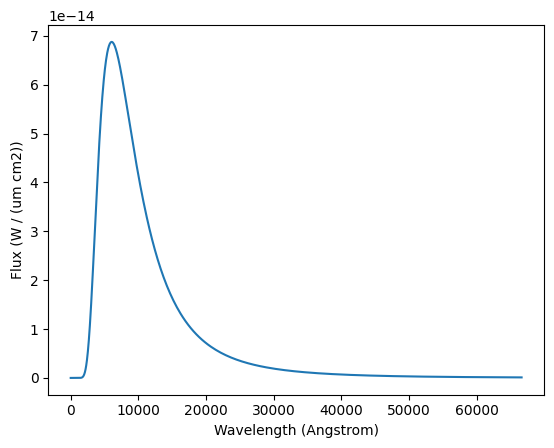

In [8]:
from synphot.models import BlackBodyNorm1D, Empirical1D

# check normalization in V band
sp = SourceSpectrum(BlackBodyNorm1D, temperature=4783.9) # kap Lyr, Gaia DR3
bp_v = SpectralElement.from_filter('johnson_v')
klyr_V = 4.34 # kap Lyr
obs_vega = Observation(SourceSpectrum.from_vega(), bp_v)
vega_rate = obs_vega.countrate(A)
sp_star = sp.normalize(klyr_V * synphot.units.VEGAMAG, bp_v, vegaspec=SourceSpectrum.from_vega())#, area=A)
sp_star.plot(flux_unit=W_cm2_um)

obs_check = Observation(sp_star, bp_v)
star_rate_check = obs_check.countrate(A)
print(star_rate_check)
mag = (-2.5 * np.log10(star_rate_check / vega_rate))
print('mag', mag, 'mag error:', klyr_V - mag)

# # check normalization in R band
# sp = SourceSpectrum(BlackBodyNorm1D, temperature=4783.9) # kap Lyr, Gaia DR3
# sp = SourceSpectrum(BlackBodyNorm1D, temperature=4203.5) # HD 168322, Gaia DR3
# bp_r = SpectralElement.from_filter('johnson_r')
# klyr_R = 3.48 # https://irsa.ipac.caltech.edu/workspace/TMP_aTDFUf_946502/DUST/alf_Lyr.v0001/extinction.html, CTIO R
# obs_vega = Observation(SourceSpectrum.from_vega(), bp_r)
# vega_rate = obs_vega.countrate(A)
# sp_star = sp.normalize(klyr_R * synphot.units.VEGAMAG, bp_r, vegaspec=SourceSpectrum.from_vega(), area=A)
# sp_star.plot(flux_unit=W_cm2_um)

# obs_check = Observation(sp_star, bp_r)
# star_rate_check = obs_check.countrate(A)
# print(star_rate_check)
# mag = (-2.5 * np.log10(star_rate_check / vega_rate))
# print('mag', mag, 'mag error:', klyr_R - (-2.5 * np.log10(star_rate_check / vega_rate)))

557608.0490298156 electron / s 25813247.767915 electron / s 27084055.111697666 ct / s
4.163784039615775


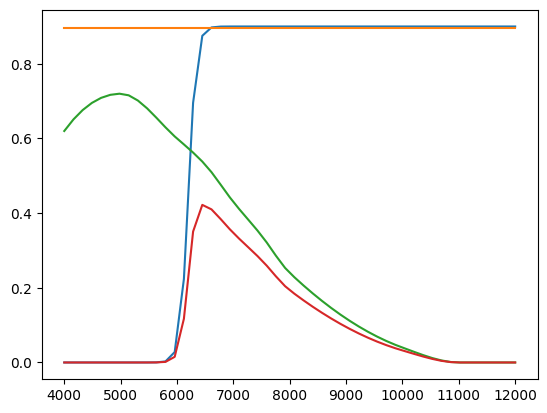

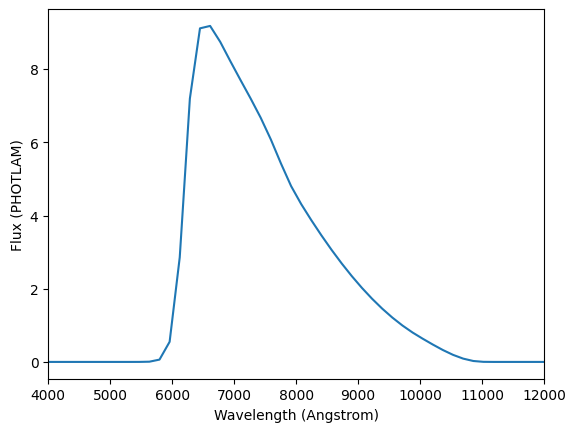

In [9]:
optics_degradation = 1

# observe with TIMcam
wave = list((np.linspace(400, 1200, num=50)*u.nm).to(u.Angstrom).value)
thru = list(optics_degradation * np.array([0.62      , 0.65113057, 0.67612491, 0.69524416, 0.70874942,
       0.7169018 , 0.71996243, 0.71563285, 0.70162448, 0.68074155,
       0.65584735, 0.62980514, 0.60547819, 0.58409068, 0.56223538,
       0.53820438, 0.50972788, 0.47614065, 0.44198079, 0.41117728,
       0.38231713, 0.35327144, 0.32149001, 0.28598099, 0.25317803,
       0.22847269, 0.2062314 , 0.1850887 , 0.16506153, 0.14616685,
       0.12842161, 0.11184278, 0.0964473 , 0.08225214, 0.06927425,
       0.05753057, 0.04703808, 0.03775721, 0.02863028, 0.01975259,
       0.01178881, 0.00540359, 0.0012616 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ]))
bp_qe = SpectralElement(Empirical1D, points=wave, lookup_table=thru, keep_neg=False)

# AR reflection losses: 0.995^(11 * 2) = 0.9
# glass absorption, 20 mm: 0.996
bp_tau = SpectralElement(Empirical1D, points=wave, lookup_table=list(optics_degradation * 0.9 * 0.996 * np.ones_like(wave)))

wave = list((np.linspace(400, 1200, num=50)*u.nm).to(u.Angstrom).value)
thru = list(optics_degradation * np.array([2.01830764e-14, 2.07645305e-13, 2.14721155e-12, 2.21470243e-11,
       2.27055444e-10, 2.34087436e-09, 2.42049049e-08, 2.49338306e-07,
       2.55620601e-06, 2.63925241e-05, 2.72714103e-04, 2.79729923e-03,
       2.79033388e-02, 2.23595264e-01, 6.95777334e-01, 8.75049586e-01,
       8.97505413e-01, 8.99757715e-01, 8.99976560e-01, 8.99997718e-01,
       8.99999778e-01, 8.99999979e-01, 8.99999998e-01, 9.00000000e-01,
       9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
       9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
       9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
       9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
       9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
       9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
       9.00000000e-01, 9.00000000e-01])) # B+W 091
# thru = list(optics_degradation * np.array([2.77795559e-16, 2.86191700e-15, 2.94841608e-14, 3.03752952e-13,
#        3.12933634e-12, 3.22391795e-11, 3.32135820e-10, 3.42174350e-09,
#        3.52516274e-08, 3.63170655e-07, 3.74145784e-06, 3.85439125e-05,
#        3.96930574e-04, 4.07256660e-03, 4.02618118e-02, 2.92899861e-01,
#        7.49256108e-01, 8.82760659e-01, 8.98297191e-01, 8.99834432e-01,
#        8.99983926e-01, 8.99998440e-01, 8.99999849e-01, 8.99999985e-01,
#        8.99999999e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
#        9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
#        9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
#        9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
#        9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
#        9.00000000e-01, 9.00000000e-01, 9.00000000e-01, 9.00000000e-01,
#        9.00000000e-01, 9.00000000e-01])) # 650 cut-on
bp_red = SpectralElement(Empirical1D, points=wave, lookup_table=thru, keep_neg=False)

bp_timcam = bp_red * bp_tau * bp_qe

fig, ax = plt.subplots()
ax.plot(bp_red.waveset, bp_red(bp_red.waveset))
ax.plot(bp_tau.waveset, bp_tau(bp_tau.waveset))
ax.plot(bp_qe.waveset, bp_qe(bp_qe.waveset))
ax.plot(bp_timcam.waveset, bp_timcam(bp_timcam.waveset))

obs_star = Observation(sp_star, bp_timcam)
obs_vega_091 = Observation(SourceSpectrum.from_vega(), bp_timcam)

obs_star.plot()
plt.gca().set_xlim(4000, 12000)

cr = obs_star.countrate(A) * (u.electron / u.ct)
cr_vega = obs_vega.countrate(A) * (u.electron / u.ct)

nominal_vega_count_rate = (1000 * u.ct / u.cm**2 / u.AA / u.s) * (A * 900 * u.AA)
print(cr, cr_vega, nominal_vega_count_rate)
# magnitude of normalized star spectrum, relative to vega in TIMcam filter
print(-2.5 * np.log10(cr/cr_vega))

In [10]:
# Vmags = np.arange(10, -1, -1)
# Teffs = np.arange(2000, 10000, 1000)
# VV, TT = np.meshgrid(Vmags, Teffs, indexing='ij')
# count_rates = np.zeros_like(VV) * u.electron / u.s
# print(Vmags.shape, count_rates.shape)
# for i, Vmag in enumerate(Vmags):
#     for j, Teff in enumerate(Teffs):
#         sp = SourceSpectrum(BlackBodyNorm1D, temperature=Teff)
#         sp_star = sp.normalize(Vmag * synphot.units.VEGAMAG, bp_v, vegaspec=SourceSpectrum.from_vega())#, area=A)
#         # sp_star.plot(flux_unit=W_cm2_um)

#         # obs_check = Observation(sp_star, bp_v)
#         # star_rate_check = obs_check.countrate(A)
#         # mag = (-2.5 * np.log10(star_rate_check / vega_rate))

#         obs_star = Observation(sp_star, bp_timcam)
#         # obs_star.plot()
#         # plt.gca().set_xlim(4000, 12000)

#         cr = obs_star.countrate(A) * (u.electron / u.ct)
#         count_rates[i][j] = cr

# import matplotlib

# fig, ax = plt.subplots()
# im = ax.pcolormesh(VV, TT, count_rates.value, norm=matplotlib.colors.LogNorm())
# fig.colorbar(im, ax=ax, label='TIMcam electron/s count rate')
# ax.set_xlabel('Johnson V Magnitude')
# ax.set_ylabel('Effective Temperature (K)')

In [11]:
bp_timcam.avgwave().to(u.nm)

<Quantity 745.65900539 nm>

Johnson R mag from a Johnson V mag

In [12]:
# show that we can do synthetic color correction: use a star's Teff to create 
# a scaled spectrum in one filter, and reproduce a measurement seen in another
# filter.
A = 1 * u.cm**2
bp_v = SpectralElement.from_filter('johnson_v')
bp_r = SpectralElement.from_filter('johnson_r')
obs_vega_v = Observation(SourceSpectrum.from_vega(), bp_v)
obs_vega_r = Observation(SourceSpectrum.from_vega(), bp_r)
cr_vega_v = obs_vega_v.countrate(A)
cr_vega_r = obs_vega_r.countrate(A)
print(cr_vega_v, cr_vega_r)

# kap Lyr, https://simbad.cds.unistra.fr/simbad/sim-id?Ident=kap+Lyr&submit=submit+id
sp = SourceSpectrum(BlackBodyNorm1D, temperature=4783.9*u.K)
Vmag = 4.34
Rmag = 3.48

sp_star = sp.normalize(Vmag * synphot.units.VEGAMAG, bp_v, vegaspec=SourceSpectrum.from_vega())
obs_star_v = Observation(sp_star, bp_v)
obs_star_r = Observation(sp_star, bp_r)
cr_star_v = obs_star_v.countrate(A)
cr_star_r = obs_star_r.countrate(A)

mag_v = -2.5 * np.log10(cr_star_v / cr_vega_v)
mag_r = -2.5 * np.log10(cr_star_r / cr_vega_r)
Vmag - mag_v, Rmag - mag_r

857771.2198307253 ct / s 1306528.2938898006 ct / s


(<Quantity -2.44668859e-05>, <Quantity -0.14266121>)

In [13]:
Vmag - -2.5 * np.log10(cr_star_v * 1.1 / cr_vega_v)

<Quantity 0.10345725>

Tycho mag from a Johnson V mag

In [14]:
# Tycho mags
A = 1 * u.cm**2
bp_t = SpectralElement.from_file('./TYCHO_TYCHO.V.dat')
bp_v = SpectralElement.from_filter('johnson_v')
obs_vega_t = Observation(SourceSpectrum.from_vega(), bp_t)
cr_vega_t = obs_vega_t.countrate(A)
print(cr_vega_t)

# kap Lyr, https://simbad.cds.unistra.fr/simbad/sim-id?Ident=kap+Lyr&submit=submit+id
sp = SourceSpectrum(BlackBodyNorm1D, temperature=4783.9*u.K)
Vmag = 4.34

sp_star = sp.normalize(Vmag * synphot.units.VEGAMAG, bp_v, vegaspec=SourceSpectrum.from_vega())
obs_star_v = Observation(sp_star, bp_v)
obs_star_t = Observation(sp_star, bp_t)
cr_star_v = obs_star_v.countrate(A)
cr_star_t = obs_star_t.countrate(A)

mag_v = -2.5 * np.log10(cr_star_v / cr_vega_v)
mag_t = -2.5 * np.log10(cr_star_t / cr_vega_t)
mag_v, mag_t

1054420.213194784 ct / s


(<Quantity 4.34002447>, <Quantity 4.45239377>)

TIMCam mag from a Tycho mag and Teff

In [15]:
f = 83.1 * u.mm
fN = 1.4
D = 61.9 * u.mm # f / fN
A = np.pi * (D/2)**2
A = A.to(u.cm**2)
print('area', D, A)

bp_t = SpectralElement.from_file('./TYCHO_TYCHO.V.dat')
obs_vega_t = Observation(SourceSpectrum.from_vega(), bp_t)
obs_vega_red = Observation(SourceSpectrum.from_vega(), bp_red)
cr_vega_t = obs_vega_t.countrate(A)
cr_vega_red = obs_vega_red.countrate(A)
print('vega counts', cr_vega_t, cr_vega_red)

sp = SourceSpectrum(BlackBodyNorm1D, temperature=6055.6*u.K)
Tmag = 10

sp_star = sp.normalize(Tmag * synphot.units.VEGAMAG, bp_t, vegaspec=SourceSpectrum.from_vega())
obs_star_t = Observation(sp_star, bp_t)
obs_star_red = Observation(sp_star, bp_red)
cr_star_t = obs_star_t.countrate(A)
cr_star_red = obs_star_red.countrate(A)

print('star counts', cr_star_t, cr_star_red)

mag_t = -2.5 * np.log10(cr_star_t / cr_vega_t)
mag_red = -2.5 * np.log10(cr_star_red / cr_vega_red)
print('star mags', mag_t, mag_red)

area 61.9 mm 30.093394568552963 cm2
vega counts 31731083.516728368 ct / s 63603705.90816422 ct / s
star counts 3172.9901764780425 ct / s 13449.766626310728 ct / s
star mags 10.000040436525508 9.186919180184196


TIMCam mag from a GAIA DR3 Rpmag

In [18]:
f = 83.1 * u.mm
fN = 1.4
D = 61.9 * u.mm # f / fN
A = np.pi * (D/2)**2
A = A.to(u.cm**2)
print('area', D, A)

bp_r = SpectralElement.from_file('./GAIA_GAIA0.Grp.dat')
obs_vega_r = Observation(SourceSpectrum.from_vega(), bp_r)
obs_vega_red = Observation(SourceSpectrum.from_vega(), bp_red)
cr_vega_r = obs_vega_r.countrate(A)
cr_vega_red = obs_vega_red.countrate(A)
print('vega counts', cr_vega_r, cr_vega_red)

sp = SourceSpectrum(BlackBodyNorm1D, temperature=4783.9*u.K)
Rmag = 3.282857

sp_star = sp.normalize(Rmag * synphot.units.VEGAMAG, bp_r, vegaspec=SourceSpectrum.from_vega())
obs_star_r = Observation(sp_star, bp_r)
obs_star_red = Observation(sp_star, bp_red)
cr_star_r = obs_star_r.countrate(A)
cr_star_red = obs_star_red.countrate(A)

print('star counts', cr_star_r, cr_star_red)

mag_r = -2.5 * np.log10(cr_star_r / cr_vega_r)
mag_red = -2.5 * np.log10(cr_star_red / cr_vega_red)
print('star mags', mag_r, mag_red)

area 61.9 mm 30.093394568552963 cm2
vega counts 40980383.30969779 ct / s 63603705.90816422 ct / s
star counts 1992655.6880349563 ct / s 3462982.5287576118 ct / s
star mags 3.2828593825756274 3.1600803008438545


Beta version of new equivalent mag function

In [17]:
def get_equivalent_mag_new(lambd, ref_mag, ref_filt, new_filt, model_flux_density):
    '''
    Use synthetic photometry to calculate the magnitude of a star in one filter
    system, given the magnitude and filter bandpass in another system.

    Parameters
    ----------
    lambd : np.ndarray
        Increasing array of wavelengths to evaluate curves at
    ref_mag : float or np.ndarray
        magnitude in reference filter system
    ref_filt : function
        Evaluatable over lambd, the reference filter system bandpass
    new_filt : function
        Evaluatable over lambd, the new filter system bandpass
    model_flux_density : function
        Evaluatable over lambd, the flux density model for the star in question,
        in or convertible to W/cm^2/um.
    '''
    def core(lambd, ref_mag, ref_filt, new_filt, model_flux_density):
        '''
        Helper to encapsulate synphot stuff, to allow broadcasting one level
        above.
        '''
        # Load in the model spectrum from Teff and Planck law
        src_norm = SourceSpectrum(
            Empirical1D,
            points=lambd.to(u.AA),
            lookup_table=model_flux_density(lambd).to(u.W / u.cm**2 / u.AA)
        )
        
        # Renormalize the curve, given the reference magnitude, Vega spectrum, and
        # reference system filter bandpass.
        # This gives the star the correct spectral content and amplitude to
        # reproduce the given magnitude in the given system.
        bandpass_ref = SpectralElement(
            Empirical1D,
            points=lambd.to(u.AA),
            lookup_table=ref_filt.tau(lambd)
        )
        src = src_norm.normalize(ref_mag * units.VEGAMAG, bandpass_ref, vegaspec=SourceSpectrum.from_vega())

        # Observe the reference spectrum and scaled spectrum in the new filter
        # system
        bandpass_new = SpectralElement(
            Empirical1D,
            points=lambd.to(u.AA),
            lookup_table=new_filt.tau(lambd)
        )
        obs_vega_new = Observation(SourceSpectrum.from_vega(), bandpass_new)
        obs_src_new = Observation(src, bandpass_new)
        # the new magnitude is the ratio of count rates to Vega in the new filter
        # system
        A = 1 * u.cm**2
        counts_vega_new = obs_vega_new.countrate(A)
        counts_src_new = obs_src_new.countrate(A)
        return -2.5 * np.log10(counts_src_new / counts_vega_new)

    if np.isscalar(ref_mag):
        return core(lambd, ref_mag, ref_filt, new_filt, model_flux_density)
    else:
        args = [
            [lambd] * len(ref_mag),
            ref_mag,
            [ref_filt] * len(ref_mag),
            [new_filt] * len(ref_mag),
            [model_flux_density] * len(ref_mag),
        ]
        return np.array(list(map(core, *args)))